# Library Import

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)

# DataFrame Creation

In [4]:
# Tabela de obras
obras = pd.DataFrame({
    "obra_id": [1, 2, 3, 4, 5],
    "nome_obra": ["Torre A", "Torre B", "Torre C", "Torre D", "Torre E"],
    "pavimentos": [5, 6, 7, 4, 8],
    "status": ["ativa"] * 5,
    "fase_inicial": ["acelerada"] * 5
})
# Timeline
datas = pd.date_range(start="2025-01-01", periods=90)

# Baseline
fator = 8 # m³ de agua por pavimento por dia
obras["consumo_base_m3"] = obras["pavimentos"] * fator

obras

,obra_id,nome_obra,pavimentos,status,fase_inicial,consumo_base_m3
0,1,Torre A,5,ativa,acelerada,40
1,2,Torre B,6,ativa,acelerada,48
2,3,Torre C,7,ativa,acelerada,56
3,4,Torre D,4,ativa,acelerada,32
4,5,Torre E,8,ativa,acelerada,64


# Water Consumption Model

In [66]:
def nome_fase(dia):
    if dia <= 30:
        return "Acelerada"
    elif dia <= 60:
        return "Intermediária"
    else:
        return "Redução"

def fator_fase(fase):
    fatores = {
        "Acelerada": 1.2,
        "Intermediária": 1.0,
        "Redução": 0.85
    }
    return fatores[fase]

registros = []

for _, obra in obras.iterrows():
    
    base = obra["consumo_base_m3"]
    torre = obra["nome_obra"]
    ruido_anterior = 1
    
    for i, data in enumerate(datas, start=1):
        
        n_fase = nome_fase(i)
        fator = fator_fase(n_fase)
        consumo_dia = base * fator

        # Noise creation
        erro = np.random.normal(0, 0.03)
        ruido = 0.6 * (ruido_anterior - 1) + erro + 1
        consumo_dia = base * fator * ruido
        
        # Leak Simulation
        if torre == 'Torre D' and i >= 35:
            fator_vazamento = 1 + 0.01 * (i - 35)
            consumo_dia *= fator_vazamento
        
    
        ruido_anterior = ruido
        
        registros.append({
            "dia_obra": i,
            "data": data,
            "obra_id": obra["obra_id"],
            "nome_obra": obra["nome_obra"],
            "fase": n_fase,
            "consumo_m3": consumo_dia
        })

consumo_agua = pd.DataFrame(registros)

consumo_agua.tail()

,dia_obra,data,obra_id,nome_obra,fase,consumo_m3
445,86,2025-03-27,5,Torre E,Redução,54.853744
446,87,2025-03-28,5,Torre E,Redução,53.517401
447,88,2025-03-29,5,Torre E,Redução,52.708173
448,89,2025-03-30,5,Torre E,Redução,53.204298
449,90,2025-03-31,5,Torre E,Redução,52.219259


# Auxiliary Functions

In [67]:
def filtrar_obra(df, nome):
    if nome not in df["nome_obra"].unique():
        raise ValueError("Obra não encontrada")
    return df[df["nome_obra"] == nome].copy()

def filtrar_fase(df, fase):
    if fase not in df["fase"].unique():
        raise ValueError("Fase não encontrada.")
    return df[df["fase"] == fase].copy()

# Exploratory Data Analysis (EDA)

## DF Overview

In [68]:
consumo_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dia_obra    450 non-null    int64         
 1   data        450 non-null    datetime64[ns]
 2   obra_id     450 non-null    int64         
 3   nome_obra   450 non-null    object        
 4   fase        450 non-null    object        
 5   consumo_m3  450 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 21.2+ KB


In [69]:
consumo_agua.describe()

,dia_obra,data,obra_id,consumo_m3
count,450.000000,450,450.000000,450.000000
mean,45.500000,2025-02-14 11:59:59.999999744,3.000000,49.755173
min,1.000000,2025-01-01 00:00:00,1.000000,29.942695
25%,23.000000,2025-01-23 00:00:00,2.000000,39.292377
50%,45.500000,2025-02-14 12:00:00,3.000000,48.108062
75%,68.000000,2025-03-09 00:00:00,4.000000,57.595656
max,90.000000,2025-03-31 00:00:00,5.000000,81.950713
std,26.008072,NaN,1.415788,12.636054


## Temporal Series

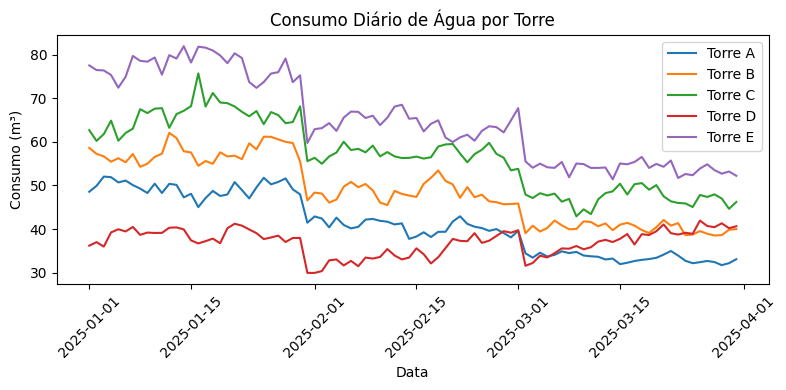

In [70]:
plt.figure(figsize=(8,4))

for nome_obra, df_obra in consumo_agua.groupby("nome_obra"):
    plt.plot(df_obra["data"], df_obra["consumo_m3"], label=nome_obra)

plt.title("Consumo Diário de Água por Torre")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Torre D apresenta comportamento anômalo crescente após 1 etapa.

## Tower Comparison

### BoxPlot

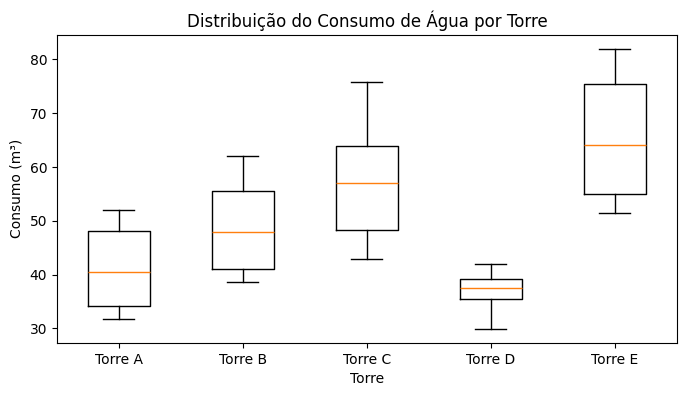

In [71]:
dados_boxplot = [
    df["consumo_m3"].values
    for _, df in consumo_agua.groupby("nome_obra")
]

labels = consumo_agua["nome_obra"].unique()

plt.figure(figsize=(8,4))
plt.boxplot(dados_boxplot, labels=labels)
plt.title("Distribuição do Consumo de Água por Torre")
plt.xlabel("Torre")
plt.ylabel("Consumo (m³)")
plt.show()

Torre D desvia do padrão crescente esperado entre torres, com menor variação no consumo.

### Average Consumption by Tower

In [72]:
media = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .mean()
    .sort_values()
    .to_frame("Average Consumption (m³)")
)

display(media)

,Average Consumption (m³)
nome_obra,
Torre D,36.986611
Torre A,41.094861
Torre B,48.677334
Torre C,56.833156
Torre E,65.183903


Apesar de possuir mais pavimentos que A, B e C, torre D apresenta consumo médio inferior.

### Standard Deviation by Tower

In [73]:
std = (
    consumo_agua.groupby("nome_obra")["consumo_m3"]
    .std()
    .sort_values()
    .to_frame("Standard Deviation (m³)")
)

display(std)

,Standard Deviation (m³)
nome_obra,
Torre D,2.958678
Torre A,6.723872
Torre B,7.352044
Torre C,8.111587
Torre E,9.921852


O menor desvio padrão da Torre D, apesar da menor quantidade de pavimentos, sugere comportamento atípico do consumo ao longo do tempo, especialmente nas etapas posteriores da obra.

## Tower D Anomaly Evaluation

### Temporal Series

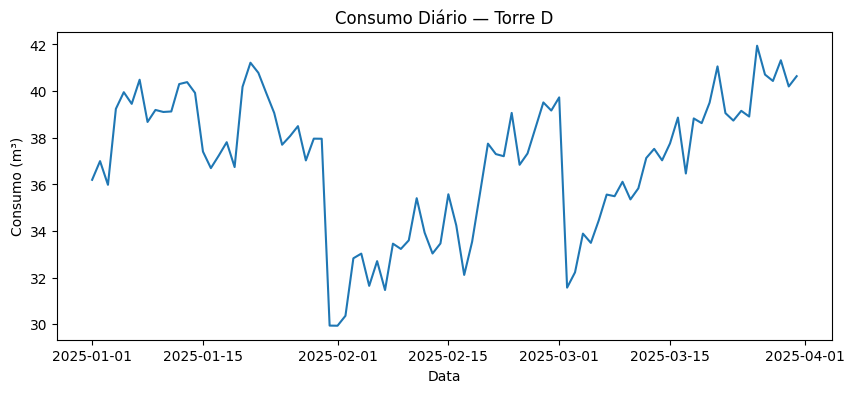

In [74]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

plt.figure(figsize=(10,4))
plt.plot(torre_d["data"], torre_d["consumo_m3"])
plt.title("Consumo Diário — Torre D")
plt.xlabel("Data")
plt.ylabel("Consumo (m³)")
plt.show()

### Tower D vs Others Comparison

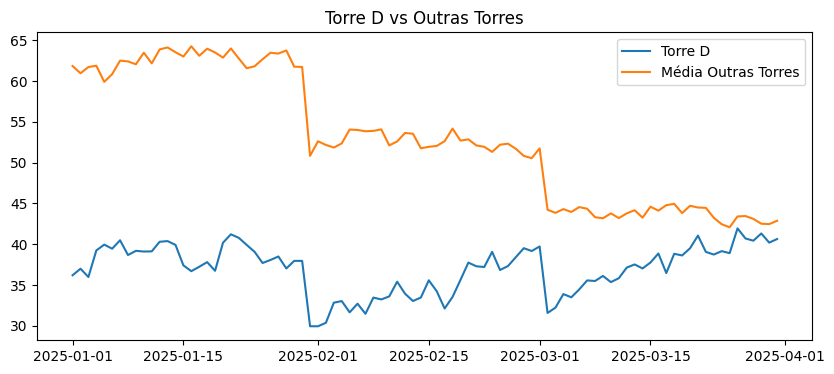

In [75]:
media_por_data = consumo_agua.groupby(["data","nome_obra"])["consumo_m3"].mean().unstack()

plt.figure(figsize=(10,4))
plt.plot(media_por_data.index, media_por_data["Torre D"], label="Torre D")

outras = media_por_data.drop(columns="Torre D").mean(axis=1)
plt.plot(media_por_data.index, outras, label="Média Outras Torres")

plt.legend()
plt.title("Torre D vs Outras Torres")
plt.show()

Observa-se que o perfil de consumo na Torre D diverge daquele observado na média das demais - consistentes entre si

## Linear Regression

In [76]:
torre_d = torre_d.reset_index(drop=True)

X = pd.Series(range(len(torre_d["consumo_m3"])))
Y = torre_d["consumo_m3"]

# Adicionando o intercepto
X = sm.add_constant(X)

# Criando e ajustando o modelo
model_rlint = sm.OLS(Y, X)
results_rlint = model_rlint.fit()

# Exibindo o sumário do modelo
print(results_rlint.summary())

                            OLS Regression Results                            
Dep. Variable:             consumo_m3   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.3159
Date:                Thu, 12 Feb 2026   Prob (F-statistic):              0.575
Time:                        14:59:28   Log-Likelihood:                -224.67
No. Observations:                  90   AIC:                             453.3
Df Residuals:                      88   BIC:                             458.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.6852      0.621     59.077      0.0

A análise de regressão não detectou uma tendência linear estatisticamente significativa no consumo de água ao longo do tempo (p = 0,382, R^2 = 0,009). Isso sugere que um modelo linear simples é insuficiente para capturar o comportamento anormal observado na Torre D, indicando que o padrão de consumo pode envolver uma mudança estrutural, em vez de uma tendência contínua.

### Phase Analisys

In [83]:
torre_d = filtrar_obra(consumo_agua, "Torre D")

fases = ["Acelerada", "Intermediária", "Redução"]

for fase in fases:
    
    df_fase = filtrar_fase(torre_d, fase).reset_index(drop=True)
    
    X = pd.Series(range(len(df_fase)), name="tempo")
    X = sm.add_constant(X)
    Y = df_fase["consumo_m3"]
    
    results = sm.OLS(Y, X).fit()
    
    coef = results.params.iloc[1]
    pval = results.pvalues.iloc[1]
    
    print(f"Fase: {fase}")
    print(f"Coeficiente tempo: {coef:.4f}")
    print(f"P-value: {pval:.4f}")
    print("-"*40)

Fase: Acelerada
Coeficiente tempo: 0.0032
P-value: 0.9184
----------------------------------------
Fase: Intermediária
Coeficiente tempo: 0.3057
P-value: 0.0000
----------------------------------------
Fase: Redução
Coeficiente tempo: 0.2930
P-value: 0.0000
----------------------------------------


### Hypothesis Test

H₀: Não há tendência de crescimento no consumo ao longo do tempo dentro da fase ($β₁ = 0$).  
H₁: Há tendência positiva de crescimento no consumo ao longo do tempo dentro da fase ($β₁ > 0$).

Um modelo de regressão linear foi aplicado separadamente em cada fase da construção para avaliar se o consumo de água apresentava uma tendência positiva estatisticamente significativa ao longo do tempo.

Durante a fase acelerada, o consumo permaneceu estatisticamente estável ($p = 0,918$), não havendo evidência para rejeição da hipótese nula, o que indica comportamento operacional normal.

Entretanto, tendências positivas estatisticamente significativas foram identificadas tanto na fase intermediária quanto na fase de redução ($p < 0,001$), permitindo rejeitar H₀ nessas fases. Esse resultado sugere crescimento anormal do consumo, consistente com a dinâmica esperada de um vazamento progressivo.

# Business Impact

## Baseline / Benchmark

In [89]:
# Filtrar fases
fases_vazamento = ["Intermediária", "Redução"]
df_vaz = consumo_agua[consumo_agua["fase"].isin(fases_vazamento)].copy()

# Separar Torre D
df_d = df_vaz[df_vaz["nome_obra"] == "Torre D"].copy()
df_outras = df_vaz[df_vaz["nome_obra"] != "Torre D"].copy()

# Calculo de pavimentos
pav_D = obras.loc[obras["nome_obra"] == "Torre D", "pavimentos"].values[0]
pav_outras = obras.loc[obras["nome_obra"] != "Torre D", "pavimentos"].sum()

# Consumo total outras
consumo_outras_dia = (
    df_outras
    .groupby("data")["consumo_m3"]
    .sum()
    .reset_index()
)

# Baseline Torre D
consumo_outras_dia["baseline_D"] = (
    consumo_outras_dia["consumo_m3"] / pav_outras
) * pav_D

# Associar ao real D
df_d = df_d[["data", "consumo_m3"]].rename(
    columns={"consumo_m3": "consumo_real_D"}
)

df_compare = df_d.merge(consumo_outras_dia[["data", "baseline_D"]],
                        on="data")

## Overconsumption Calculation

In [90]:
df_compare["excesso"] = (
    df_compare["consumo_real_D"] - df_compare["baseline_D"]
)

excesso_total = df_compare["excesso"].sum()

percentual = (
    excesso_total / df_compare["baseline_D"].sum()
) * 100

print(f"Excesso acumulado: {excesso_total:.2f} m³")
print(f"Percentual acima do esperado: {percentual:.2f}%")

Excesso acumulado: 393.41 m³
Percentual acima do esperado: 22.15%


## Conclusion

Durante as fases intermediária e de redução, a Torre D apresentou consumo aproximadamente $393 m³$ acima do benchmark operacional, calculado com base em construções de porte similar e ajustado pelo número de pavimentos. Esse valor corresponde a um excesso de $22,15%$ em relação ao consumo esperado.

A variação observada é estatisticamente significativa e consistente com a dinâmica de vazamento progressivo identificada na análise temporal, indicando ineficiência operacional com impacto mensurável em recursos hídricos e custos financeiros.